<a href="https://colab.research.google.com/github/nayankhanal/ml-class/blob/main/time_series_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data.csv')

In [3]:
df.head()

,date,sales,temperature,promo
0,2024-01-01,102.48,20.54,0
1,2024-01-02,113.42,22.48,0
2,2024-01-03,122.53,24.84,0
3,2024-01-04,140.91,26.23,1
4,2024-01-05,100.96,23.82,0


In [5]:
df['date'] = pd.to_datetime(df['date'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         200 non-null    datetime64[ns]
 1   sales        200 non-null    float64       
 2   temperature  200 non-null    float64       
 3   promo        200 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 6.4 KB


In [8]:
df = df.sort_values('date')
df.reset_index(drop=True, inplace=True)

In [9]:
df.head()

,date,sales,temperature,promo
0,2024-01-01,102.48,20.54,0
1,2024-01-02,113.42,22.48,0
2,2024-01-03,122.53,24.84,0
3,2024-01-04,140.91,26.23,1
4,2024-01-05,100.96,23.82,0


In [13]:
df = df.set_index('date')
df.head()

,sales,temperature,promo
date,,,
2024-01-01,102.48,20.54,0
2024-01-02,113.42,22.48,0
2024-01-03,122.53,24.84,0
2024-01-04,140.91,26.23,1
2024-01-05,100.96,23.82,0


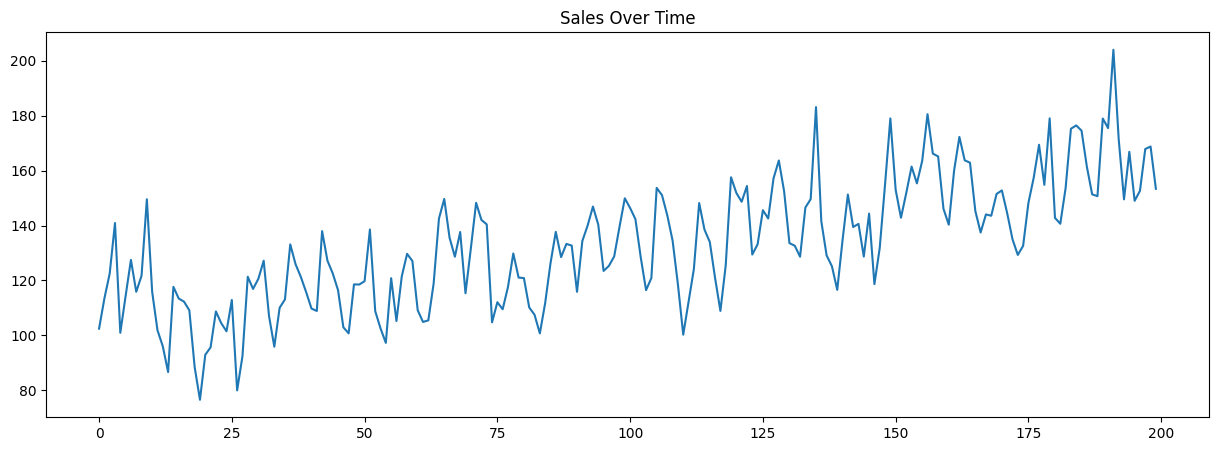

In [11]:
plt.figure(figsize=(15,5))
plt.plot(df['sales'])
plt.title("Sales Over Time")
plt.show()

In [14]:
df['year'] = df.index.year

In [15]:
df.head()

,sales,temperature,promo,year
date,,,,
2024-01-01,102.48,20.54,0,2024
2024-01-02,113.42,22.48,0,2024
2024-01-03,122.53,24.84,0,2024
2024-01-04,140.91,26.23,1,2024
2024-01-05,100.96,23.82,0,2024


In [16]:
df['month'] = df.index.month
df.head()

,sales,temperature,promo,year,month
date,,,,,
2024-01-01,102.48,20.54,0,2024,1
2024-01-02,113.42,22.48,0,2024,1
2024-01-03,122.53,24.84,0,2024,1
2024-01-04,140.91,26.23,1,2024,1
2024-01-05,100.96,23.82,0,2024,1


In [17]:
df['dayofweek'] = df.index.dayofweek
df.head()

,sales,temperature,promo,year,month,dayofweek
date,,,,,,
2024-01-01,102.48,20.54,0,2024,1,0
2024-01-02,113.42,22.48,0,2024,1,1
2024-01-03,122.53,24.84,0,2024,1,2
2024-01-04,140.91,26.23,1,2024,1,3
2024-01-05,100.96,23.82,0,2024,1,4


In [18]:
df['dayofweek'] = df.index.dayofyear
df.head()

,sales,temperature,promo,year,month,dayofweek
date,,,,,,
2024-01-01,102.48,20.54,0,2024,1,1
2024-01-02,113.42,22.48,0,2024,1,2
2024-01-03,122.53,24.84,0,2024,1,3
2024-01-04,140.91,26.23,1,2024,1,4
2024-01-05,100.96,23.82,0,2024,1,5


In [19]:
df.sample(5)

,sales,temperature,promo,year,month,dayofweek
date,,,,,,
2024-01-30,116.93,18.71,0,2024,1,30
2024-04-04,140.32,24.84,0,2024,4,95
2024-05-08,163.66,28.66,0,2024,5,129
2024-04-27,108.93,12.96,0,2024,4,118
2024-06-02,161.44,21.27,1,2024,6,154


In [20]:
df['weekofyear'] = df.index.isocalendar().week.astype(int)
df.head()

,sales,temperature,promo,year,month,dayofweek,weekofyear
date,,,,,,,
2024-01-01,102.48,20.54,0,2024,1,1,1
2024-01-02,113.42,22.48,0,2024,1,2,1
2024-01-03,122.53,24.84,0,2024,1,3,1
2024-01-04,140.91,26.23,1,2024,1,4,1
2024-01-05,100.96,23.82,0,2024,1,5,1


In [23]:
df['is_weekend'] = np.where(
    df.index.dayofweek >= 5,
    1,
    0
    )
df.sample(5)

,sales,temperature,promo,year,month,dayofweek,weekofyear,is_weekend
date,,,,,,,,
2024-02-15,116.48,20.53,0,2024,2,46,7,0
2024-05-30,152.99,17.13,0,2024,5,151,22,0
2024-05-25,144.34,12.39,1,2024,5,146,21,1
2024-05-15,183.08,22.80,1,2024,5,136,20,0
2024-01-04,140.91,26.23,1,2024,1,4,1,0


In [24]:
df['month_sin'] = np.sin(2*np.pi*df['month']/12)
df['month_cos'] = np.cos(2*np.pi*df['month']/12)

df

,sales,temperature,promo,year,month,dayofweek,weekofyear,is_weekend,month_sin,month_cos
date,,,,,,,,,,
2024-01-01,102.48,20.54,0,2024,1,1,1,0,0.5,0.866025
2024-01-02,113.42,22.48,0,2024,1,2,1,0,0.5,0.866025
2024-01-03,122.53,24.84,0,2024,1,3,1,0,0.5,0.866025
2024-01-04,140.91,26.23,1,2024,1,4,1,0,0.5,0.866025
2024-01-05,100.96,23.82,0,2024,1,5,1,0,0.5,0.866025
...,...,...,...,...,...,...,...,...,...,...
2024-07-14,148.99,23.54,0,2024,7,196,28,1,-0.5,-0.866025
2024-07-15,152.60,20.20,0,2024,7,197,29,0,-0.5,-0.866025
2024-07-16,167.83,23.20,0,2024,7,198,29,0,-0.5,-0.866025


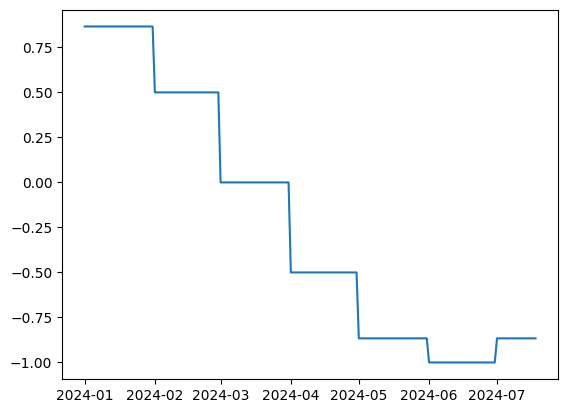

In [25]:
plt.plot(df['month_cos'])
plt.show()

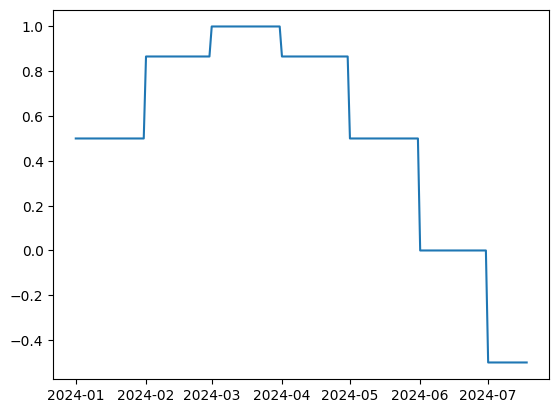

In [26]:
plt.plot(df['month_sin'])
plt.show()

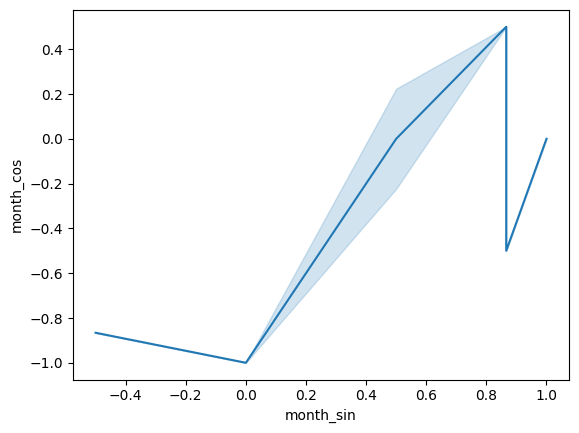

In [27]:
sns.lineplot(data=df, x=df['month_sin'], y=df['month_cos'])
plt.show()

In [ ]:
# np.sin(2*np.pi*4/12) # april

In [29]:
df['sales_lag_1'] = df['sales'].shift(1)
df['sales_lag_7'] = df['sales'].shift(7)

In [30]:
df

,sales,temperature,promo,year,month,dayofweek,weekofyear,is_weekend,month_sin,month_cos,sales_lag_1,sales_lag_7
date,,,,,,,,,,,,
2024-01-01,102.48,20.54,0,2024,1,1,1,0,0.5,0.866025,NaN,NaN
2024-01-02,113.42,22.48,0,2024,1,2,1,0,0.5,0.866025,102.48,NaN
2024-01-03,122.53,24.84,0,2024,1,3,1,0,0.5,0.866025,113.42,NaN
2024-01-04,140.91,26.23,1,2024,1,4,1,0,0.5,0.866025,122.53,NaN
2024-01-05,100.96,23.82,0,2024,1,5,1,0,0.5,0.866025,140.91,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-14,148.99,23.54,0,2024,7,196,28,1,-0.5,-0.866025,166.81,150.67
2024-07-15,152.60,20.20,0,2024,7,197,29,0,-0.5,-0.866025,148.99,178.92
2024-07-16,167.83,23.20,0,2024,7,198,29,0,-0.5,-0.866025,152.60,175.44


In [31]:
df['rolling_mean_7'] = df['sales'].shift(1).rolling(7).mean()
df.head(12)

,sales,temperature,promo,year,month,dayofweek,weekofyear,is_weekend,month_sin,month_cos,sales_lag_1,sales_lag_7,rolling_mean_7
date,,,,,,,,,,,,,
2024-01-01,102.48,20.54,0,2024,1,1,1,0,0.5,0.866025,NaN,NaN,NaN
2024-01-02,113.42,22.48,0,2024,1,2,1,0,0.5,0.866025,102.48,NaN,NaN
2024-01-03,122.53,24.84,0,2024,1,3,1,0,0.5,0.866025,113.42,NaN,NaN
2024-01-04,140.91,26.23,1,2024,1,4,1,0,0.5,0.866025,122.53,NaN,NaN
2024-01-05,100.96,23.82,0,2024,1,5,1,0,0.5,0.866025,140.91,NaN,NaN
2024-01-06,114.37,25.46,1,2024,1,6,1,1,0.5,0.866025,100.96,NaN,NaN
2024-01-07,127.49,28.34,1,2024,1,7,1,1,0.5,0.866025,114.37,NaN,NaN
2024-01-08,115.89,28.71,0,2024,1,8,2,0,0.5,0.866025,127.49,102.48,117.451429
2024-01-09,121.74,28.75,0,2024,1,9,2,0,0.5,0.866025,115.89,113.42,119.367143


In [32]:
df['diff_1'] = df['sales'] - df['sales'].shift(1)
df.head()

,sales,temperature,promo,year,month,dayofweek,weekofyear,is_weekend,month_sin,month_cos,sales_lag_1,sales_lag_7,rolling_mean_7,diff_1
date,,,,,,,,,,,,,,
2024-01-01,102.48,20.54,0,2024,1,1,1,0,0.5,0.866025,NaN,NaN,NaN,NaN
2024-01-02,113.42,22.48,0,2024,1,2,1,0,0.5,0.866025,102.48,NaN,NaN,10.94
2024-01-03,122.53,24.84,0,2024,1,3,1,0,0.5,0.866025,113.42,NaN,NaN,9.11
2024-01-04,140.91,26.23,1,2024,1,4,1,0,0.5,0.866025,122.53,NaN,NaN,18.38
2024-01-05,100.96,23.82,0,2024,1,5,1,0,0.5,0.866025,140.91,NaN,NaN,-39.95


In [33]:
corr = df.corr()
corr

,sales,temperature,promo,year,month,dayofweek,weekofyear,is_weekend,month_sin,month_cos,sales_lag_1,sales_lag_7,rolling_mean_7,diff_1
sales,1.000000,0.280031,0.229357,NaN,0.780577,0.757597,0.768194,-0.320526,-0.586274,-0.731578,0.781855,0.768687,0.775678,0.326795
temperature,0.280031,1.000000,0.027068,NaN,0.102198,-0.006333,-0.006862,-0.001386,-0.152686,-0.053702,0.297924,0.197266,0.354410,-0.026197
promo,0.229357,0.027068,1.000000,NaN,-0.068864,-0.060190,-0.060884,0.079513,-0.048133,0.097852,-0.092201,-0.077131,-0.028711,0.484217
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,0.780577,0.102198,-0.068864,NaN,1.000000,0.988762,0.988338,0.002095,-0.691850,-0.958700,0.779046,0.755048,0.943080,-0.004012
dayofweek,0.757597,-0.006333,-0.060190,NaN,0.988762,1.000000,0.999402,0.005401,-0.675647,-0.954010,0.757019,0.746652,0.917729,-0.005991
weekofyear,0.768194,-0.006862,-0.060884,NaN,0.988338,0.999402,1.000000,-0.021920,-0.676362,-0.953237,0.759230,0.758015,0.917362,0.006894
is_weekend,-0.320526,-0.001386,0.079513,NaN,0.002095,0.005401,-0.021920,1.000000,0.017439,-0.009079,-0.274902,-0.334964,0.000193,-0.077052
month_sin,-0.586274,-0.152686,-0.048133,NaN,-0.691850,-0.675647,-0.676362,0.017439,1.000000,0.504195,-0.586429,-0.615356,-0.740400,-0.002038
month_cos,-0.731578,-0.053702,0.097852,NaN,-0.958700,-0.954010,-0.953237,-0.009079,0.504195,1.000000,-0.730772,-0.695684,-0.877700,0.005893


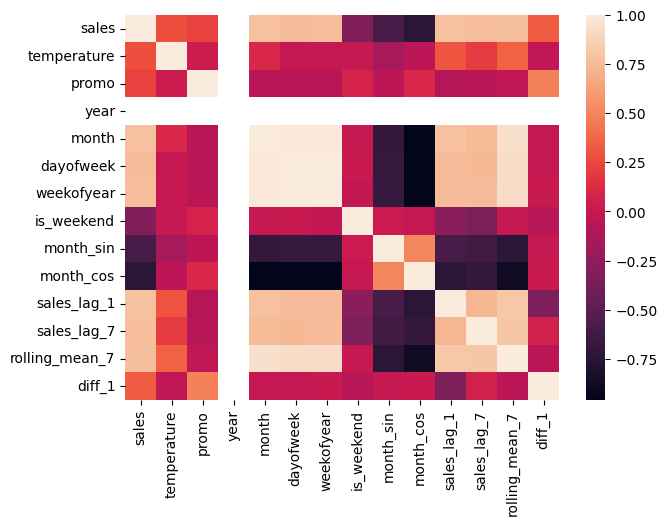

In [37]:
plt.figure(figsize=(7,5))
sns.heatmap(corr)
plt.show()

In [38]:
df.isnull().sum()

,0
sales,0
temperature,0
promo,0
year,0
month,0
dayofweek,0
weekofyear,0
is_weekend,0
month_sin,0
month_cos,0


In [42]:
df = df.dropna()

In [43]:
df.isnull().sum()

,0
sales,0
temperature,0
promo,0
year,0
month,0
dayofweek,0
weekofyear,0
is_weekend,0
month_sin,0
month_cos,0


# Moving Average (MA) & Exponential Moving Average (EMA)

In [44]:
# MA --> 100, 120, 90 (33%, 33%, 33%)
# EMA --> 100, 120, 90 (50%, 30%, 20%)

In [45]:
df2 = pd.read_csv('data.csv')
df2.head()

,date,sales,temperature,promo
0,2024-01-01,102.48,20.54,0
1,2024-01-02,113.42,22.48,0
2,2024-01-03,122.53,24.84,0
3,2024-01-04,140.91,26.23,1
4,2024-01-05,100.96,23.82,0


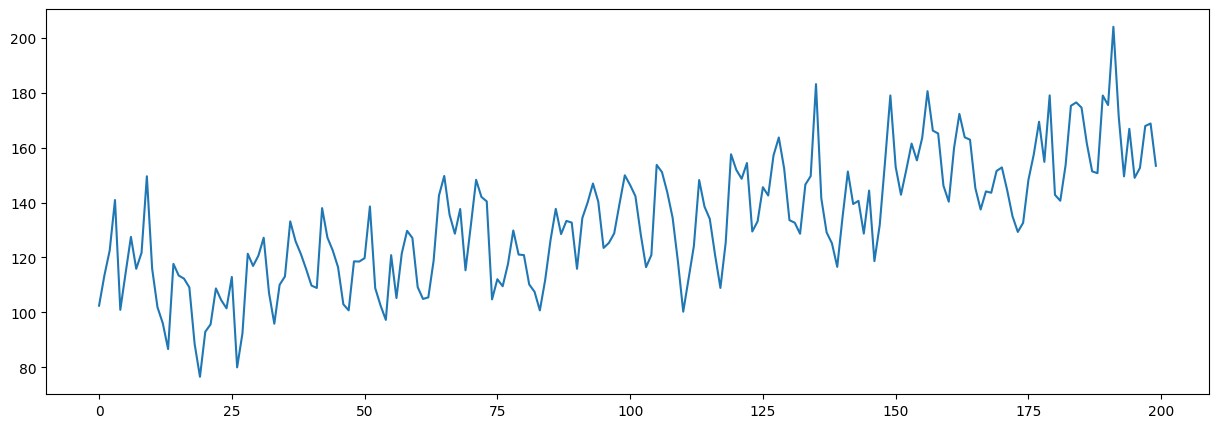

In [46]:
plt.figure(figsize=(15,5))
plt.plot(df2['sales'])
plt.show()

In [47]:
df['MA_3'] = df['sales'].shift(1).rolling(3).mean()
df['MA_7'] = df['sales'].shift(1).rolling(7).mean()
df['MA_30'] = df['sales'].shift(1).rolling(30).mean()

/tmp/ipykernel_1650/1705130427.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['MA_3'] = df['sales'].shift(1).rolling(3).mean()
/tmp/ipykernel_1650/1705130427.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['MA_7'] = df['sales'].shift(1).rolling(7).mean()
/tmp/ipykernel_1650/1705130427.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyd

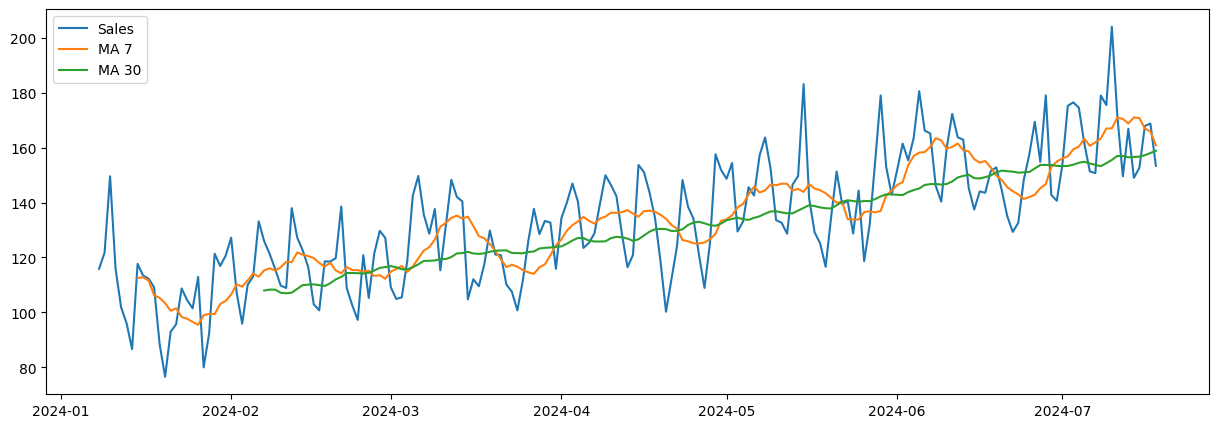

In [50]:
plt.figure(figsize=(15,5))
plt.plot(df['sales'], label='Sales')
plt.plot(df['MA_7'], label='MA 7')
plt.plot(df['MA_30'], label='MA 30')
plt.legend()
plt.show()

In [51]:
df['EMA_7'] = df['sales'].shift(1).ewm(span=7).mean()
df['EMA_30'] = df['sales'].shift(1).ewm(span=30).mean()

/tmp/ipykernel_1650/1035756668.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['EMA_7'] = df['sales'].shift(1).ewm(span=7).mean()
/tmp/ipykernel_1650/1035756668.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['EMA_30'] = df['sales'].shift(1).ewm(span=30).mean()


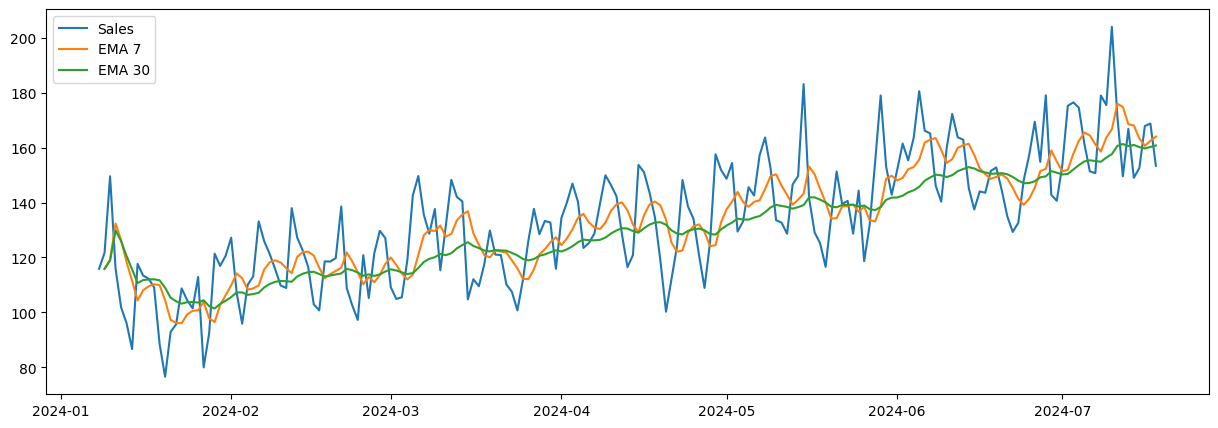

In [53]:
plt.figure(figsize=(15,5))
plt.plot(df['sales'], label='Sales')
plt.plot(df['EMA_7'], label='EMA 7')
plt.plot(df['EMA_30'], label='EMA 30')
plt.legend()
plt.show()